In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sentiment-analysis-on-movie-reviews/sampleSubmission.csv
/kaggle/input/sentiment-analysis-on-movie-reviews/train.tsv.zip
/kaggle/input/sentiment-analysis-on-movie-reviews/test.tsv.zip


In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
print("TF version: ", tf.__version__)


TF version:  2.4.1


In [4]:
if tf.__version__ < "2.0.0":
    tf.enable_eager_execution()
    print("Eager execution enabled.")
else:
    print("Eager execution enabled by default.")

Eager execution enabled by default.


In [5]:
train = pd.read_csv('../input/sentiment-analysis-on-movie-reviews/train.tsv.zip', sep = '\t')
test = pd.read_csv('../input/sentiment-analysis-on-movie-reviews/test.tsv.zip', sep = '\t')

In [6]:
print(train.shape)
print(test.shape)

(156060, 4)
(66292, 3)


In [7]:
train.head()

,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


In [8]:
test.head()

,PhraseId,SentenceId,Phrase
0,156061,8545,An intermittently pleasing but mostly routine ...
1,156062,8545,An intermittently pleasing but mostly routine ...
2,156063,8545,An
3,156064,8545,intermittently pleasing but mostly routine effort
4,156065,8545,intermittently pleasing but mostly routine


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156060 entries, 0 to 156059
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   PhraseId    156060 non-null  int64 
 1   SentenceId  156060 non-null  int64 
 2   Phrase      156060 non-null  object
 3   Sentiment   156060 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 4.8+ MB


In [10]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66292 entries, 0 to 66291
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   PhraseId    66292 non-null  int64 
 1   SentenceId  66292 non-null  int64 
 2   Phrase      66292 non-null  object
dtypes: int64(2), object(1)
memory usage: 1.5+ MB


In [11]:
import nltk
from tqdm import tqdm
from nltk.tokenize import word_tokenize 
from nltk.stem import WordNetLemmatizer
import re

In [12]:
def sentence_cleaning(df):
    sentence = []
    for sent in tqdm(df['Phrase']):
        
        text = re.sub("[^a-zA-Z]"," ",sent)
        
        word = word_tokenize(text.lower())
        
        lemmatizer = WordNetLemmatizer()
        
        lemm_word = [lemmatizer.lemmatize(i) for i in word]
        
        sentence.append(lemm_word)
    return (sentence)


In [13]:
train_sent = sentence_cleaning(train)
test_sent = sentence_cleaning(test)

100%|██████████| 66292/66292 [00:10<00:00, 6525.18it/s]


In [14]:
train_sent[0]

['a',
 'series',
 'of',
 'escapade',
 'demonstrating',
 'the',
 'adage',
 'that',
 'what',
 'is',
 'good',
 'for',
 'the',
 'goose',
 'is',
 'also',
 'good',
 'for',
 'the',
 'gander',
 'some',
 'of',
 'which',
 'occasionally',
 'amuses',
 'but',
 'none',
 'of',
 'which',
 'amount',
 'to',
 'much',
 'of',
 'a',
 'story']

In [15]:
train['Phrase'][0]

'A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .'

In [16]:
print((' ').join(train_sent[0]))

a series of escapade demonstrating the adage that what is good for the goose is also good for the gander some of which occasionally amuses but none of which amount to much of a story


In [17]:
from keras.utils import to_categorical

In [18]:
target_col = train.Sentiment.values
y_target = to_categorical(target_col)

In [19]:
y_target.shape

(156060, 5)

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train,X_val,y_train,y_val = train_test_split(train_sent,y_target,test_size =0.2,stratify = y_target)

In [22]:
X_train[11]

['a',
 'beguiling',
 'serenity',
 'and',
 'poise',
 'that',
 'make',
 'it',
 'accessible',
 'for',
 'a',
 'non',
 'narrative',
 'feature']

In [23]:
print(len(X_train))
print(len(X_val))

124848
31212


In [24]:
unique_words = set()
max_len = 0
for sent in tqdm(X_train):
    unique_words.update(sent)
    if(max_len < len(sent)):
        max_len = len(sent)
        sentence = sent

100%|██████████| 124848/124848 [00:00<00:00, 591070.98it/s]


In [25]:
print('Number of vocabs: ', len(list(unique_words)))
print('Max length of text is: ', max_len)

Number of vocabs:  13742
Max length of text is:  48


In [26]:
sentence

['it',
 's',
 'a',
 'bad',
 'sign',
 'when',
 'you',
 're',
 'rooting',
 'for',
 'the',
 'film',
 'to',
 'hurry',
 'up',
 'and',
 'get',
 'to',
 'it',
 'subject',
 'death',
 'just',
 'so',
 'the',
 'documentary',
 'will',
 'be',
 'over',
 'but',
 'it',
 's',
 'indicative',
 'of',
 'how',
 'uncompelling',
 'the',
 'movie',
 'is',
 'unless',
 'it',
 'happens',
 'to',
 'cover',
 'your',
 'particular',
 'area',
 'of',
 'interest']

In [27]:
vocabulary = len(list(unique_words))
#max_len = max_len
oov = '<OOV>'
embedding_dim = 300
padding = 'post'
trunc = 'post'

In [28]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [29]:
tokenizer = Tokenizer(num_words = vocabulary,oov_token = oov,char_level = False)

In [30]:
tokenizer.fit_on_texts(list(X_train))

In [31]:
X_train = tokenizer.texts_to_sequences(X_train)
X_train = pad_sequences(X_train,maxlen = max_len,padding=padding,truncating = trunc)

In [32]:
X_val = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(X_val,maxlen = max_len,padding=padding,truncating = trunc)

In [33]:
X_test = tokenizer.texts_to_sequences(test_sent)
X_test = pad_sequences(X_test,maxlen = max_len,padding=padding,truncating = trunc)

In [34]:
print("X_training shape   : ",X_train.shape)
print("X_validation shape : ",X_val.shape)
print("X_testing shape    : ",X_test.shape)

X_training shape   :  (124848, 48)
X_validation shape :  (31212, 48)
X_testing shape    :  (66292, 48)


In [35]:
X_train[11]

array([   3, 4915, 4916,    5, 8461,   11,   45,    7, 1836,   15,    3,
        973,  323,  252,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0], dtype=int32)

In [36]:
from keras.layers import Embedding,Bidirectional,Dense,LSTM,Dropout

In [37]:
model = tf.keras.Sequential()

In [38]:
model.add(Embedding(vocabulary,embedding_dim,input_length = max_len))
model.add(Bidirectional(LSTM(128, dropout = 0.8, recurrent_dropout=0.8, return_sequences=True)))
model.add(Bidirectional(LSTM(64,dropout = 0.5,recurrent_dropout=0.5,return_sequences=False)))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(5,activation='softmax'))
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 48, 300)           4122600   
_________________________________________________________________
bidirectional (Bidirectional (None, 48, 256)           439296    
_________________________________________________________________
bidirectional_1 (Bidirection (None, 128)               164352    
_________________________________________________________________
dense (Dense)                (None, 128)               16512     
_________________________________________________________________
dropout (Dropout)            (None, 128)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 5)                 645       
Total params: 4,743,405
Trainable params: 4,743,405
Non-trainable params: 0
______________________________________________

In [39]:
num_epochs = 5

history = model.fit(X_train,
                    y_train,
                    validation_data = (X_val, y_val),
                    epochs = num_epochs,
                    batch_size = 256,
                    verbose = 1,
                    )

Epoch 1/5
488/488 [==============================] - 403s 805ms/step - loss: 1.1901 - accuracy: 0.5318 - val_loss: 0.8736 - val_accuracy: 0.6453
Epoch 2/5
488/488 [==============================] - 395s 808ms/step - loss: 0.8598 - accuracy: 0.6547 - val_loss: 0.8368 - val_accuracy: 0.6573
Epoch 3/5
488/488 [==============================] - 398s 816ms/step - loss: 0.7913 - accuracy: 0.6787 - val_loss: 0.8158 - val_accuracy: 0.6611
Epoch 4/5
488/488 [==============================] - 398s 815ms/step - loss: 0.7539 - accuracy: 0.6922 - val_loss: 0.8092 - val_accuracy: 0.6629
Epoch 5/5
488/488 [==============================] - 398s 815ms/step - loss: 0.7134 - accuracy: 0.7058 - val_loss: 0.8084 - val_accuracy: 0.6683


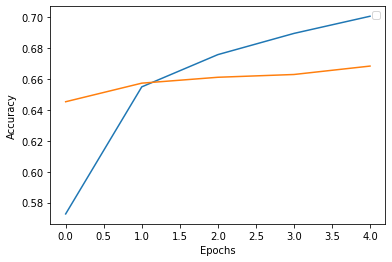

In [40]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

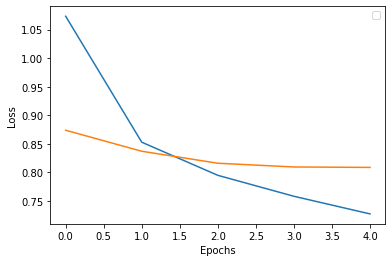

In [41]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [42]:
pred = np.argmax(model.predict(X_test),axis=-1)

In [43]:
test_id = test['PhraseId']

In [44]:
submission = pd.DataFrame({'PhraseID':test_id,'Sentiment':pred})
submission.to_csv('Submission.csv', index=False)
submission.head()

,PhraseID,Sentiment
0,156061,2
1,156062,2
2,156063,2
3,156064,2
4,156065,2
